# Linear Regression in R

This notebook reads employee salary and years-of-experience data from `regression_data.csv`, fits a simple linear regression model with **Salary** as the outcome and **YearsExperience** as the predictor, reports model statistics, and plots the data with the fitted regression line.

## Load libraries

Load **ggplot2** for plotting. Base R provides the `lm()` function used to fit the regression model.

In [1]:
library(ggplot2)

## Load the data

Read `regression_data.csv` from the same folder as this notebook into an R data frame.

In [2]:
data <- read.csv("regression_data.csv")
head(data)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


## Fit the linear regression model

Fit **Salary ~ YearsExperience** using ordinary least squares (OLS) linear regression with `lm()`.

In [3]:
model <- lm(Salary ~ YearsExperience, data = data)

## Model statistics

Print the coefficient of determination (R²) and p-values for the intercept and predictor. The slope-intercept formula and R² are also displayed at the top of the figure.

In [4]:
model_summary <- summary(model)
r_squared <- model_summary$r.squared
p_values <- coef(model_summary)[, "Pr(>|t|)"]

cat(sprintf("R-squared: %.4f\n", r_squared))
cat(sprintf("p-value (Intercept): %.4e\n", p_values["(Intercept)"]))
cat(sprintf("p-value (YearsExperience): %.4e\n", p_values["YearsExperience"]))

R-squared: 0.7852


p-value (Intercept): 9.8450e-05


p-value (YearsExperience): 6.4065e-04


## Scatter plot with fitted regression line

Plot the observed data as a scatter plot and overlay the fitted regression line. The title and axis labels use the outcome and predictor variable names.

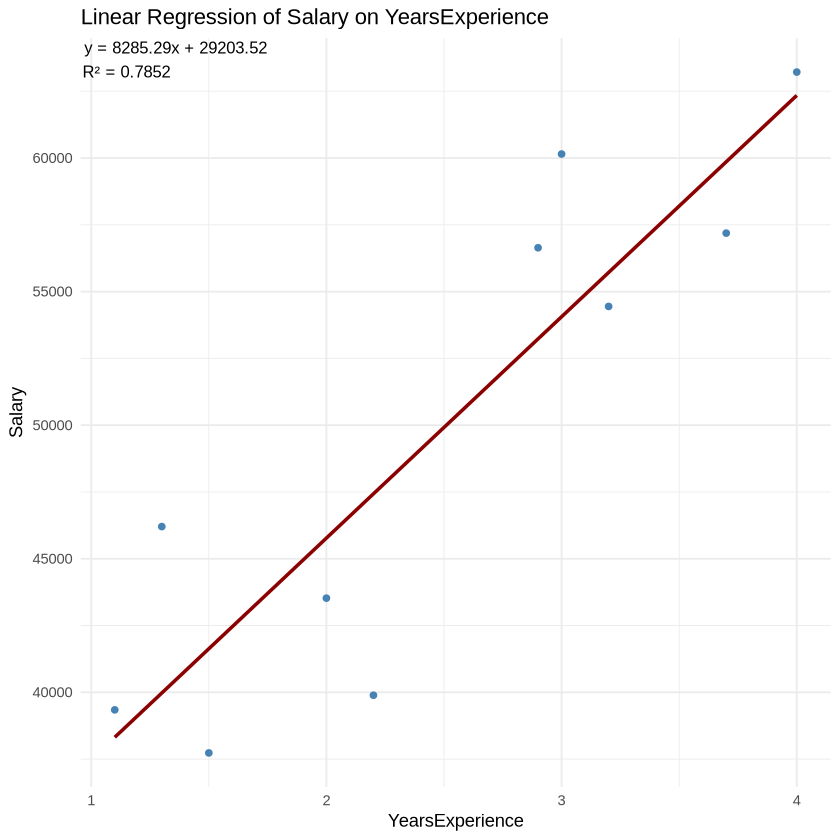

In [5]:
intercept <- coef(model)["(Intercept)"]
slope <- coef(model)[["YearsExperience"]]
formula_text <- sprintf("y = %.2fx + %.2f", slope, intercept)
r2_text <- sprintf("R² = %.4f", r_squared)
annotation_text <- paste(formula_text, r2_text, sep = "\n")

ggplot(data, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "steelblue") +
  geom_line(
    aes(y = predict(model)),
    color = "darkred",
    linewidth = 1
  ) +
  annotate(
    "text",
    x = -Inf,
    y = Inf,
    label = annotation_text,
    hjust = -0.02,
    vjust = 1.1,
    size = 3.5
  ) +
  labs(
    title = "Linear Regression of Salary on YearsExperience",
    x = "YearsExperience",
    y = "Salary"
  ) +
  theme_minimal()